# Optuna Logistic Regression Feature Test

This notebook keeps the same train/test split, CV settings, and Logistic Regression Optuna search setup as `main_Optuna_automated.ipynb`, while:

1. applying custom stop words to the word TF-IDF vectorizer,
2. searching which engineered features to keep with Optuna,
3. reporting how each engineered feature affects the score.


In [1]:
import pickle
import re

import contractions
import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd

from optuna.samplers import TPESampler
from scipy.sparse import csr_matrix, hstack
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, f1_score, precision_score, recall_score, roc_auc_score
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.preprocessing import StandardScaler

print('All imports OK')
print(f'optuna version: {optuna.__version__}')


d:\Code\Repos\CPE232\project\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


All imports OK
optuna version: 4.8.0


In [2]:
DATA_PATH = '../data/train.csv'
LABEL_COLUMNS_TO_DROP = ['severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']

SEARCH_RANDOM_STATE = 42
SEARCH_TEST_SIZE = 0.20
SEARCH_CV_SPLITS = 3
OPTUNA_TRIALS_PER_MODEL = 20
SEARCH_CLASS_WEIGHTS = ['balanced', {0: 1, 1: 3}]

custom_stopwords = list(
    set(ENGLISH_STOP_WORDS) - {'not', 'no', 'never'}
)

WORD_TFIDF_CONFIG = {
    'ngram_range': (1, 2),
    'max_features': 10000,
    'min_df': 2,
    'max_df': 0.9,
    'sublinear_tf': True,
    'stop_words': custom_stopwords,
}
CHAR_TFIDF_CONFIG = {
    'analyzer': 'char_wb',
    'ngram_range': (3, 5),
    'max_features': 10000,
    'min_df': 2,
    'sublinear_tf': True,
}
SCALER_CONFIG = {'with_mean': False}

LR_OPTUNA_MODEL_BASE_CONFIG = {
    'max_iter': 1000,
    'random_state': SEARCH_RANDOM_STATE,
    'n_jobs': None,
    'solver': 'liblinear',
}
LR_OPTUNA_C_RANGE = (3e-2, 3.0)
LR_OPTUNA_TOL_RANGE = (1e-5, 1e-3)

FEATURE_TEST_WORD_VECTORIZER_PATH = 'optuna_feature_test_word_vectorizer.pkl'
FEATURE_TEST_CHAR_VECTORIZER_PATH = 'optuna_feature_test_char_vectorizer.pkl'
FEATURE_TEST_SCALER_PATH = 'optuna_feature_test_scaler.pkl'
FEATURE_TEST_MODEL_PATH = 'optuna_feature_test_best_model.pkl'
FEATURE_TEST_METADATA_PATH = 'optuna_feature_test_metadata.pkl'

print(f'Custom stop word count: {len(custom_stopwords):,}')
print('Vectorizer config ready')


Custom stop word count: 315
Vectorizer config ready


In [3]:
df = pd.read_csv(DATA_PATH)
df = df.drop(columns=LABEL_COLUMNS_TO_DROP)

def clean_text(text):
    if not isinstance(text, str):
        return ''
    text = text.lower()
    text = contractions.fix(text)
    text = re.sub(r'http\S+|www\S+', ' URL ', text)
    text = re.sub(r'[^a-z]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['raw_text'] = df['comment_text'].fillna('').astype(str)
df['clean_text'] = df['raw_text'].apply(clean_text)
df = df[df['clean_text'] != ''].copy()
df = df.drop_duplicates(subset=['clean_text']).reset_index(drop=True)

print(f'Dataset shape after cleaning: {df.shape}')
print(df['toxic'].value_counts())


Dataset shape after cleaning: (158194, 5)
toxic
0    143038
1     15156
Name: count, dtype: int64


In [4]:
PROFANITY_TERMS = [
    'fuck', 'fucking', 'shit', 'bitch', 'bastard', 'asshole', 'idiot', 'moron',
    'dumb', 'stupid', 'suck', 'crap', 'damn', 'jerk', 'loser', 'trash'
]
IDENTITY_TERMS = [
    'black', 'white', 'gay', 'lesbian', 'transgender', 'trans', 'muslim',
    'jewish', 'christian', 'hispanic', 'asian', 'woman', 'women', 'man', 'men'
]
SECOND_PERSON_TERMS = ['you', 'your', 'yours', 'yourself', 'u']
NEGATION_TERMS = ['not', 'never', 'no', 'none', 'cannot', 'cant', 'do not']
NON_TOXIC_NEGATION_PATTERNS = [
    r'\bnot\s+(?:stupid|dumb|idiot|moron|trash|wrong|bad|terrible|awful|useless)\b',
    r'\bnot\s+(?:an|a)\s+(?:idiot|moron|loser|bastard|fool)\b',
    r'\bdo\s+not\s+(?:like|love|agree|hate|dislike|attack|insult|blame)\b',
    r'\bcannot\s+(?:hate|blame)\b',
    r'\bnot\s+trying\s+to\s+(?:attack|insult|offend)\b'
]
COMMON_SHORT_TOKENS = {
    'i', 'me', 'my', 'you', 'your', 'yours', 'yourself', 'it', 'this', 'that',
    'a', 'an', 'the', 'is', 'am', 'are', 'was', 'were', 'be', 'to', 'of', 'and'
}

def make_term_pattern(terms):
    escaped = sorted((re.escape(t) for t in terms), key=len, reverse=True)
    return re.compile(r'\b(?:' + '|'.join(escaped) + r')\b')

PROFANITY_PATTERN = make_term_pattern(PROFANITY_TERMS)
IDENTITY_PATTERN = make_term_pattern(IDENTITY_TERMS)
SECOND_PERSON_PATTERN = make_term_pattern(SECOND_PERSON_TERMS)
NEGATION_PATTERN = make_term_pattern(NEGATION_TERMS)
NON_TOXIC_NEGATION_PATTERN = re.compile('|'.join(NON_TOXIC_NEGATION_PATTERNS))

def count_pattern(text, pattern):
    return len(pattern.findall(str(text).lower()))

def repeated_characters_score(text):
    return len(re.findall(r'(.)\1{2,}', str(text).lower()))

def repeated_punctuation_count(text):
    return len(re.findall(r'([!?.,])\1+', str(text)))

def uppercase_ratio(text):
    letters = re.findall(r'[A-Za-z]', str(text))
    if not letters:
        return 0.0
    return sum(1 for c in letters if c.isupper()) / len(letters)

def short_unclear_without_toxic_signal(clean_text, profanity_count):
    tokens = str(clean_text).split()
    content_tokens = [t for t in tokens if t not in COMMON_SHORT_TOKENS]
    too_short = len(tokens) < 3 or len(content_tokens) < 1
    return int(too_short and profanity_count == 0)

print('Feature helper functions ready')


Feature helper functions ready


In [5]:
df['Character Count'] = df['raw_text'].apply(len)
df['Word Count'] = df['clean_text'].apply(lambda x: len(x.split()))
df['Exclamation Count'] = df['raw_text'].str.count('!')
df['Profanity Count'] = df['clean_text'].apply(lambda x: count_pattern(x, PROFANITY_PATTERN))
df['Strong Toxic Signal Flag'] = (df['Profanity Count'] > 0).astype(int)
df['Second-person Pronoun Count'] = df['clean_text'].apply(lambda x: count_pattern(x, SECOND_PERSON_PATTERN))
df['Repeated Character Pattern Count'] = df['raw_text'].apply(repeated_characters_score)
df['Average Word Length'] = df['clean_text'].apply(
    lambda x: sum(len(w) for w in x.split()) / len(x.split()) if x.split() else 0
)

df['Uppercase Ratio'] = df['raw_text'].apply(uppercase_ratio)
df['Question Mark Count'] = df['raw_text'].str.count(r'\?')
df['Repeated Punctuation Count'] = df['raw_text'].apply(repeated_punctuation_count)
df['Identity-group Term Count'] = df['clean_text'].apply(lambda x: count_pattern(x, IDENTITY_PATTERN))
df['URL Count'] = df['raw_text'].str.count(r'http\S+|www\S+')
df['Negation Count'] = df['clean_text'].apply(lambda x: count_pattern(x, NEGATION_PATTERN))
df['Non-toxic Negation Pattern Count'] = df['clean_text'].apply(lambda x: count_pattern(x, NON_TOXIC_NEGATION_PATTERN))
df['Short/Unclear Without Toxic Signal Flag'] = df.apply(
    lambda row: short_unclear_without_toxic_signal(row['clean_text'], row['Profanity Count']),
    axis=1
)

ENG_FEATURE_COLS = [
    'Character Count', 'Word Count', 'Exclamation Count',
    'Profanity Count', 'Strong Toxic Signal Flag',
    'Second-person Pronoun Count', 'Repeated Character Pattern Count',
    'Average Word Length',
    'Uppercase Ratio', 'Question Mark Count', 'Repeated Punctuation Count',
    'Identity-group Term Count', 'URL Count', 'Negation Count',
    'Non-toxic Negation Pattern Count', 'Short/Unclear Without Toxic Signal Flag'
]

print(f'Engineered feature count: {len(ENG_FEATURE_COLS)}')
print(df[ENG_FEATURE_COLS].head(3))


Engineered feature count: 16
   Character Count  Word Count  Exclamation Count  Profanity Count  \
0              264          46                  0                0   
1              112          16                  1                0   
2              233          44                  0                0   

   Strong Toxic Signal Flag  Second-person Pronoun Count  \
0                         0                            0   
1                         0                            0   
2                         0                            0   

   Repeated Character Pattern Count  Average Word Length  Uppercase Ratio  \
0                                 0             4.478261         0.083744   
1                                 0             4.625000         0.109589   
2                                 0             4.272727         0.021505   

   Question Mark Count  Repeated Punctuation Count  Identity-group Term Count  \
0                    1                           0         

In [6]:
X_raw = df['raw_text']
X_clean = df['clean_text']
X_eng = df[ENG_FEATURE_COLS]
y = df['toxic']

(
    X_raw_train, X_raw_test,
    X_clean_train, X_clean_test,
    X_eng_train, X_eng_test,
    y_train, y_test
) = train_test_split(
    X_raw, X_clean, X_eng, y,
    test_size=SEARCH_TEST_SIZE,
    random_state=SEARCH_RANDOM_STATE,
    stratify=y
)

print(f'Train: {len(y_train):,} | Test: {len(y_test):,}')
print(f'Toxic ratio (train): {y_train.mean():.3f}')


Train: 126,555 | Test: 31,639
Toxic ratio (train): 0.096


In [7]:
word_vec = TfidfVectorizer(**WORD_TFIDF_CONFIG)
X_word_train = word_vec.fit_transform(X_clean_train)
X_word_test = word_vec.transform(X_clean_test)

char_vec = TfidfVectorizer(**CHAR_TFIDF_CONFIG)
X_char_train = char_vec.fit_transform(X_raw_train)
X_char_test = char_vec.transform(X_raw_test)

scaler = StandardScaler(**SCALER_CONFIG)
X_eng_train_scaled = csr_matrix(scaler.fit_transform(X_eng_train.values))
X_eng_test_scaled = csr_matrix(scaler.transform(X_eng_test.values))

X_text_train = hstack([X_word_train, X_char_train], format='csr')
X_text_test = hstack([X_word_test, X_char_test], format='csr')
X_all_train = hstack([X_text_train, X_eng_train_scaled], format='csr')
X_all_test = hstack([X_text_test, X_eng_test_scaled], format='csr')

ENG_FEATURE_INDEX = {feature: idx for idx, feature in enumerate(ENG_FEATURE_COLS)}
FEATURE_FLAG_NAMES = {
    feature: 'use_' + re.sub(r'[^a-z0-9]+', '_', feature.lower()).strip('_')
    for feature in ENG_FEATURE_COLS
}

print(f'Word TF-IDF shape: {X_word_train.shape}')
print(f'Char TF-IDF shape: {X_char_train.shape}')
print(f'Text-only matrix: {X_text_train.shape}')
print(f'All-feature matrix: {X_all_train.shape}')


Word TF-IDF shape: (126555, 10000)
Char TF-IDF shape: (126555, 10000)
Text-only matrix: (126555, 20000)
All-feature matrix: (126555, 20016)


In [8]:
search_cv = StratifiedKFold(
    n_splits=SEARCH_CV_SPLITS,
    shuffle=True,
    random_state=SEARCH_RANDOM_STATE
)

def suggest_class_weight(trial, prefix):
    idx = trial.suggest_int(f'{prefix}_class_weight_idx', 0, len(SEARCH_CLASS_WEIGHTS) - 1)
    return SEARCH_CLASS_WEIGHTS[idx]

def build_feature_matrix(text_matrix, eng_matrix, selected_features):
    if not selected_features:
        return text_matrix
    feature_indices = [ENG_FEATURE_INDEX[feature] for feature in selected_features]
    return hstack([text_matrix, eng_matrix[:, feature_indices]], format='csr')

def suggest_selected_features(trial):
    selected = []
    for feature in ENG_FEATURE_COLS:
        use_feature = trial.suggest_categorical(FEATURE_FLAG_NAMES[feature], [True, False])
        if use_feature:
            selected.append(feature)
    return selected

def objective_lr(trial):
    selected_features = suggest_selected_features(trial)
    X_trial = build_feature_matrix(X_text_train, X_eng_train_scaled, selected_features)
    model = LogisticRegression(
        **LR_OPTUNA_MODEL_BASE_CONFIG,
        penalty=trial.suggest_categorical('penalty', ['l1', 'l2']),
        C=trial.suggest_float('C', LR_OPTUNA_C_RANGE[0], LR_OPTUNA_C_RANGE[1], log=True),
        class_weight=suggest_class_weight(trial, 'lr'),
        tol=trial.suggest_float('tol', LR_OPTUNA_TOL_RANGE[0], LR_OPTUNA_TOL_RANGE[1], log=True)
    )
    trial.set_user_attr('selected_features', selected_features)
    return cross_val_score(model, X_trial, y_train, cv=search_cv, scoring='f1', n_jobs=3).mean()

print(f'Running Optuna LR feature study ({OPTUNA_TRIALS_PER_MODEL} trials x {SEARCH_CV_SPLITS}-fold)...')
lr_study = optuna.create_study(direction='maximize', sampler=TPESampler(seed=SEARCH_RANDOM_STATE))
lr_study.optimize(objective_lr, n_trials=OPTUNA_TRIALS_PER_MODEL)

def materialize_best_lr_trial(best_trial):
    params = dict(best_trial.params)
    selected_features = best_trial.user_attrs.get('selected_features', [])
    for flag_name in FEATURE_FLAG_NAMES.values():
        params.pop(flag_name, None)
    if 'lr_class_weight_idx' in params:
        params['class_weight'] = SEARCH_CLASS_WEIGHTS[params.pop('lr_class_weight_idx')]
    return params, selected_features

best_lr_params, best_selected_features = materialize_best_lr_trial(lr_study.best_trial)
X_best_train = build_feature_matrix(X_text_train, X_eng_train_scaled, best_selected_features)
X_best_test = build_feature_matrix(X_text_test, X_eng_test_scaled, best_selected_features)

best_lr = LogisticRegression(
    **LR_OPTUNA_MODEL_BASE_CONFIG,
    **best_lr_params
)
best_lr.fit(X_best_train, y_train)

print('\nOptuna search complete')
print(f'Best CV F1: {lr_study.best_value:.4f}')
print(f'Best LR params: {best_lr_params}')
print(f'Best selected engineered features ({len(best_selected_features)}): {best_selected_features}')


[I 2026-05-14 09:28:07,226] A new study created in memory with name: no-name-e7cbe133-7953-41b5-b386-db1264530ca4


Running Optuna LR feature study (20 trials x 3-fold)...


[I 2026-05-14 09:34:30,005] Trial 0 finished with value: 0.787070566076328 and parameters: {'use_character_count': False, 'use_word_count': True, 'use_exclamation_count': True, 'use_profanity_count': False, 'use_strong_toxic_signal_flag': False, 'use_second_person_pronoun_count': False, 'use_repeated_character_pattern_count': True, 'use_average_word_length': False, 'use_uppercase_ratio': False, 'use_question_mark_count': True, 'use_repeated_punctuation_count': True, 'use_identity_group_term_count': False, 'use_url_count': False, 'use_negation_count': False, 'use_non_toxic_negation_pattern_count': True, 'use_short_unclear_without_toxic_signal_flag': True, 'penalty': 'l2', 'C': 2.5608569588600485, 'lr_class_weight_idx': 1, 'tol': 4.066563313514796e-05}. Best is trial 0 with value: 0.787070566076328.
[I 2026-05-14 09:34:37,020] Trial 1 finished with value: 0.6959020019065308 and parameters: {'use_character_count': False, 'use_word_count': True, 'use_exclamation_count': True, 'use_profanit


Optuna search complete
Best CV F1: 0.7941
Best LR params: {'penalty': 'l2', 'C': 1.0645493016479186, 'tol': 0.0002226958973431528, 'class_weight': {0: 1, 1: 3}}
Best selected engineered features (7): ['Character Count', 'Profanity Count', 'Second-person Pronoun Count', 'Repeated Character Pattern Count', 'Uppercase Ratio', 'Identity-group Term Count', 'URL Count']


In [9]:
def evaluate_feature_set(name, selected_features, model_params):
    X_train_eval = build_feature_matrix(X_text_train, X_eng_train_scaled, selected_features)
    X_test_eval = build_feature_matrix(X_text_test, X_eng_test_scaled, selected_features)
    model = LogisticRegression(
        **LR_OPTUNA_MODEL_BASE_CONFIG,
        **model_params
    )
    model.fit(X_train_eval, y_train)
    y_pred = model.predict(X_test_eval)
    y_prob = model.predict_proba(X_test_eval)[:, 1]
    return {
        'name': name,
        'feature_count': len(selected_features),
        'features': ', '.join(selected_features) if selected_features else '(none)',
        'f1': f1_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred),
        'recall': recall_score(y_test, y_pred),
        'roc_auc': roc_auc_score(y_test, y_prob),
        'pred': y_pred,
        'prob': y_prob,
        'model': model
    }

text_only_result = evaluate_feature_set('Text only', [], best_lr_params)
all_feature_result = evaluate_feature_set('Text + all engineered', ENG_FEATURE_COLS, best_lr_params)
best_subset_result = evaluate_feature_set('Text + Optuna subset', best_selected_features, best_lr_params)

summary_df = pd.DataFrame([
    {k: v for k, v in text_only_result.items() if k not in {'pred', 'prob', 'model'}},
    {k: v for k, v in all_feature_result.items() if k not in {'pred', 'prob', 'model'}},
    {k: v for k, v in best_subset_result.items() if k not in {'pred', 'prob', 'model'}}
])

print(summary_df[['name', 'feature_count', 'f1', 'precision', 'recall', 'roc_auc']].to_string(index=False))

print('\nBest subset classification report')
print(classification_report(y_test, best_subset_result['pred'], target_names=['Not Toxic', 'Toxic']))


d:\Code\Repos\CPE232\project\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
d:\Code\Repos\CPE232\project\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
d:\Code\Repos\CPE232\project\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid 

                 name  feature_count       f1  precision   recall  roc_auc
            Text only              0 0.789361   0.785621 0.793138 0.974891
Text + all engineered             16 0.791025   0.785366 0.796767 0.975549
 Text + Optuna subset              7 0.792589   0.787810 0.797427 0.975790

Best subset classification report
              precision    recall  f1-score   support

   Not Toxic       0.98      0.98      0.98     28608
       Toxic       0.79      0.80      0.79      3031

    accuracy                           0.96     31639
   macro avg       0.88      0.89      0.89     31639
weighted avg       0.96      0.96      0.96     31639



In [10]:
single_feature_rows = []
for feature in ENG_FEATURE_COLS:
    result = evaluate_feature_set(feature, [feature], best_lr_params)
    single_feature_rows.append({
        'feature': feature,
        'f1': result['f1'],
        'precision': result['precision'],
        'recall': result['recall'],
        'roc_auc': result['roc_auc'],
        'delta_vs_text_only': result['f1'] - text_only_result['f1']
    })

single_feature_df = pd.DataFrame(single_feature_rows).sort_values('delta_vs_text_only', ascending=False).reset_index(drop=True)
print(single_feature_df.to_string(index=False))


d:\Code\Repos\CPE232\project\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
d:\Code\Repos\CPE232\project\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
d:\Code\Repos\CPE232\project\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid 

                                feature       f1  precision   recall  roc_auc  delta_vs_text_only
                        Character Count 0.791331   0.787582 0.795117 0.974989            0.001970
                        Uppercase Ratio 0.791209   0.786693 0.795777 0.975795            0.001847
       Repeated Character Pattern Count 0.790209   0.786976 0.793468 0.974886            0.000847
Short/Unclear Without Toxic Signal Flag 0.790087   0.786088 0.794127 0.974882            0.000726
                             Word Count 0.789828   0.785574 0.794127 0.974979            0.000466
                         Negation Count 0.789819   0.786205 0.793468 0.974921            0.000458
              Identity-group Term Count 0.789750   0.786392 0.793138 0.974885            0.000389
                              URL Count 0.789491   0.785878 0.793138 0.974893            0.000130
                      Exclamation Count 0.789430   0.785434 0.793468 0.974884            0.000069
                    

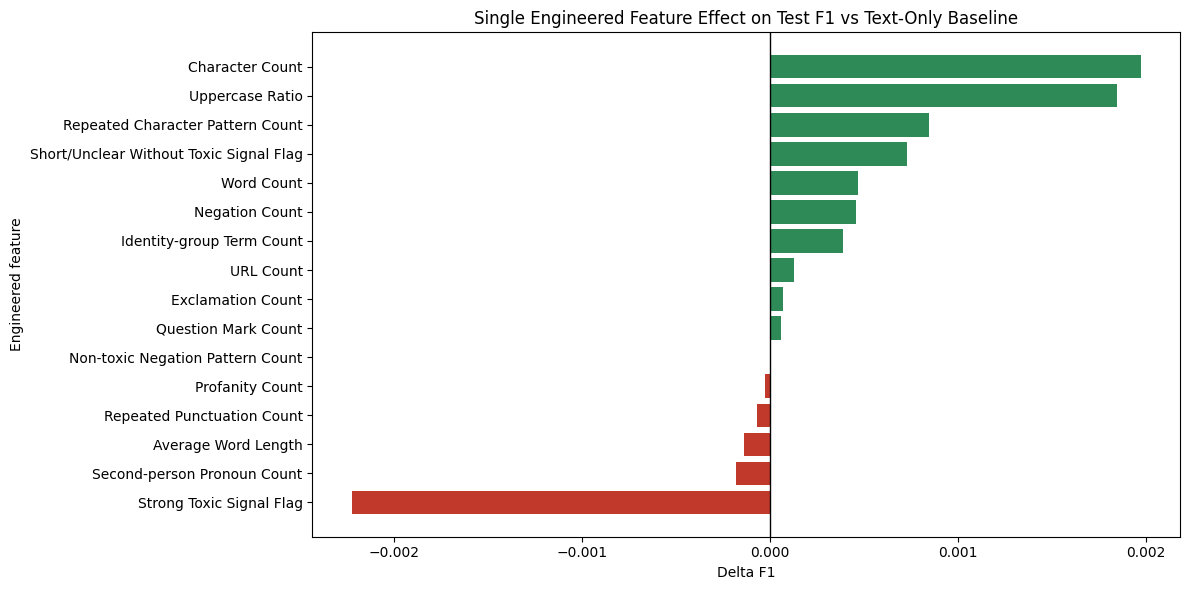

In [11]:
plt.figure(figsize=(12, 6))
plot_df = single_feature_df.sort_values('delta_vs_text_only')
colors = ['#2e8b57' if delta >= 0 else '#c0392b' for delta in plot_df['delta_vs_text_only']]
plt.barh(plot_df['feature'], plot_df['delta_vs_text_only'], color=colors)
plt.axvline(0, color='black', linewidth=1)
plt.title('Single Engineered Feature Effect on Test F1 vs Text-Only Baseline')
plt.xlabel('Delta F1')
plt.ylabel('Engineered feature')
plt.tight_layout()
plt.show()


In [12]:
drop_one_rows = []
for feature in ENG_FEATURE_COLS:
    selected = [f for f in ENG_FEATURE_COLS if f != feature]
    result = evaluate_feature_set(f'All except {feature}', selected, best_lr_params)
    drop_one_rows.append({
        'removed_feature': feature,
        'f1_without_feature': result['f1'],
        'delta_vs_all_features': result['f1'] - all_feature_result['f1']
    })

drop_one_df = pd.DataFrame(drop_one_rows).sort_values('delta_vs_all_features').reset_index(drop=True)
print(drop_one_df.to_string(index=False))


d:\Code\Repos\CPE232\project\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
d:\Code\Repos\CPE232\project\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
d:\Code\Repos\CPE232\project\.venv\Lib\site-packages\sklearn\svm\_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
d:\C

                        removed_feature  f1_without_feature  delta_vs_all_features
                        Uppercase Ratio            0.786193              -0.004832
       Repeated Character Pattern Count            0.788732              -0.002293
       Non-toxic Negation Pattern Count            0.788862              -0.002164
                        Character Count            0.789603              -0.001422
                             Word Count            0.789938              -0.001087
                      Exclamation Count            0.790059              -0.000966
                    Average Word Length            0.790075              -0.000950
              Identity-group Term Count            0.790212              -0.000813
Short/Unclear Without Toxic Signal Flag            0.790439              -0.000586
                         Negation Count            0.790637              -0.000388
            Second-person Pronoun Count            0.790713              -0.000312
    

In [13]:
with open(FEATURE_TEST_WORD_VECTORIZER_PATH, 'wb') as f:
    pickle.dump(word_vec, f)

with open(FEATURE_TEST_CHAR_VECTORIZER_PATH, 'wb') as f:
    pickle.dump(char_vec, f)

with open(FEATURE_TEST_SCALER_PATH, 'wb') as f:
    pickle.dump(scaler, f)

with open(FEATURE_TEST_MODEL_PATH, 'wb') as f:
    pickle.dump(best_lr, f)

metadata = {
    'best_cv_f1': lr_study.best_value,
    'best_lr_params': best_lr_params,
    'best_selected_features': best_selected_features,
    'summary': summary_df.drop(columns=['features']).to_dict(orient='records'),
    'single_feature_effects': single_feature_df.to_dict(orient='records'),
    'drop_one_effects': drop_one_df.to_dict(orient='records'),
    'custom_stopwords_kept_negations': ['not', 'no', 'never']
}

with open(FEATURE_TEST_METADATA_PATH, 'wb') as f:
    pickle.dump(metadata, f)

print(f'Saved: {FEATURE_TEST_MODEL_PATH}')
print(f'Saved: {FEATURE_TEST_WORD_VECTORIZER_PATH}')
print(f'Saved: {FEATURE_TEST_CHAR_VECTORIZER_PATH}')
print(f'Saved: {FEATURE_TEST_SCALER_PATH}')
print(f'Saved: {FEATURE_TEST_METADATA_PATH}')


Saved: optuna_feature_test_best_model.pkl
Saved: optuna_feature_test_word_vectorizer.pkl
Saved: optuna_feature_test_char_vectorizer.pkl
Saved: optuna_feature_test_scaler.pkl
Saved: optuna_feature_test_metadata.pkl
